In [1]:
# Install if needed (Kaggle usually has these preinstalled)
!pip install torch torchvision

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models


In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])

])
train_dir = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train"
val_dir = "/kaggle/input/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test"

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", train_dataset.classes)  # should show ['def', 'ok']


Classes: ['def_front', 'ok_front']


In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
from torchvision.models import mobilenet_v2
import torch.nn as nn

model = mobilenet_v2(weights=None)   # or weights="IMAGENET1K_V1" if you want pretrained
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)  # 2 classes
model = model.to(device)  # ✅ send model to GPU


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)




In [6]:
train_loader = DataLoader(train_dataset,
                          batch_size=64,   # larger batch size uses GPU better
                          shuffle=True,
                          num_workers=4,   # parallel data loading
                          pin_memory=True) # faster transfer to GPU

val_loader = DataLoader(val_dataset,
                        batch_size=64,
                        shuffle=False,
                        num_workers=4,
                        pin_memory=True)


In [7]:

for epoch in range(15):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # ✅ now works

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
      


    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

   

Epoch 1, Loss: 0.6332
Epoch 2, Loss: 0.4728
Epoch 3, Loss: 0.3771
Epoch 4, Loss: 0.3001
Epoch 5, Loss: 0.2395
Epoch 6, Loss: 0.1942
Epoch 7, Loss: 0.1671
Epoch 8, Loss: 0.1453
Epoch 9, Loss: 0.1121
Epoch 10, Loss: 0.1014
Epoch 11, Loss: 0.0803
Epoch 12, Loss: 0.0760
Epoch 13, Loss: 0.0774
Epoch 14, Loss: 0.0675
Epoch 15, Loss: 0.0592


In [8]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")


Validation Accuracy: 98.18%


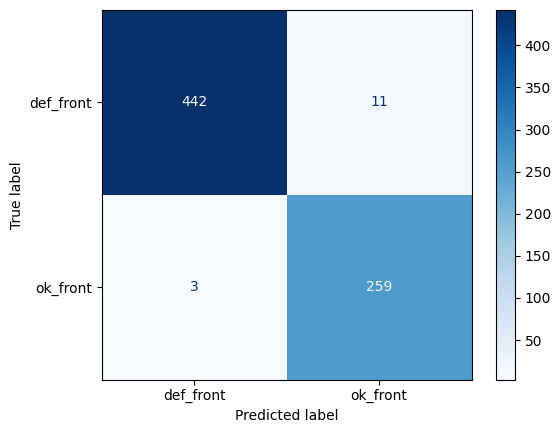

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Collect predictions and labels
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap="Blues")
